In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [8]:
df = pd.read_csv('../data/WineQT.csv')
x = df.drop(['quality', 'Id'], axis=1).values
feature_names = df.drop(['quality', 'Id'], axis=1).columns.tolist()
print(feature_names)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [22]:
summary = df.drop(["quality", "Id"], axis=1).describe().T
print(summary)

                       count       mean        std      min       25%  \
fixed acidity         1143.0   8.311111   1.747595  4.60000   7.10000   
volatile acidity      1143.0   0.531339   0.179633  0.12000   0.39250   
citric acid           1143.0   0.268364   0.196686  0.00000   0.09000   
residual sugar        1143.0   2.532152   1.355917  0.90000   1.90000   
chlorides             1143.0   0.086933   0.047267  0.01200   0.07000   
free sulfur dioxide   1143.0  15.615486  10.250486  1.00000   7.00000   
total sulfur dioxide  1143.0  45.914698  32.782130  6.00000  21.00000   
density               1143.0   0.996730   0.001925  0.99007   0.99557   
pH                    1143.0   3.311015   0.156664  2.74000   3.20500   
sulphates             1143.0   0.657708   0.170399  0.33000   0.55000   
alcohol               1143.0  10.442111   1.082196  8.40000   9.50000   

                           50%        75%        max  
fixed acidity          7.90000   9.100000   15.90000  
volatile acid

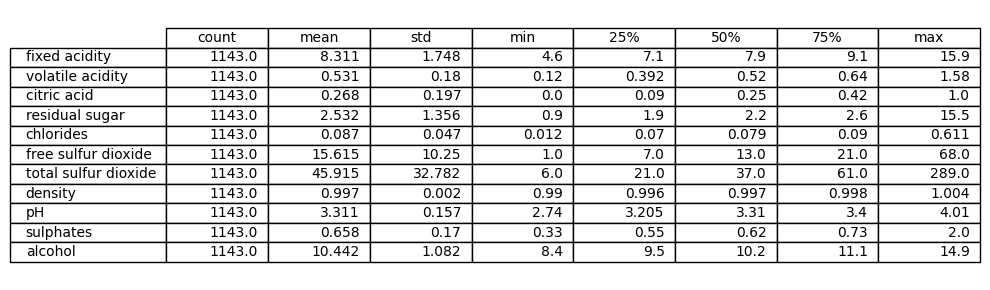

In [26]:
plt.figure(figsize=(10, 3))
plt.axis('off')
plt.table(
    cellText=summary.round(3).values,
    colLabels=summary.columns,
    rowLabels=summary.index,
    loc='center'
)
plt.tight_layout()
plt.show()

In [3]:
scaler = StandardScaler()
x_std = scaler.fit_transform(x)

In [4]:
wine_pca = PCA(n_components=x.shape[1])
x_pca = wine_pca.fit_transform(x_std)

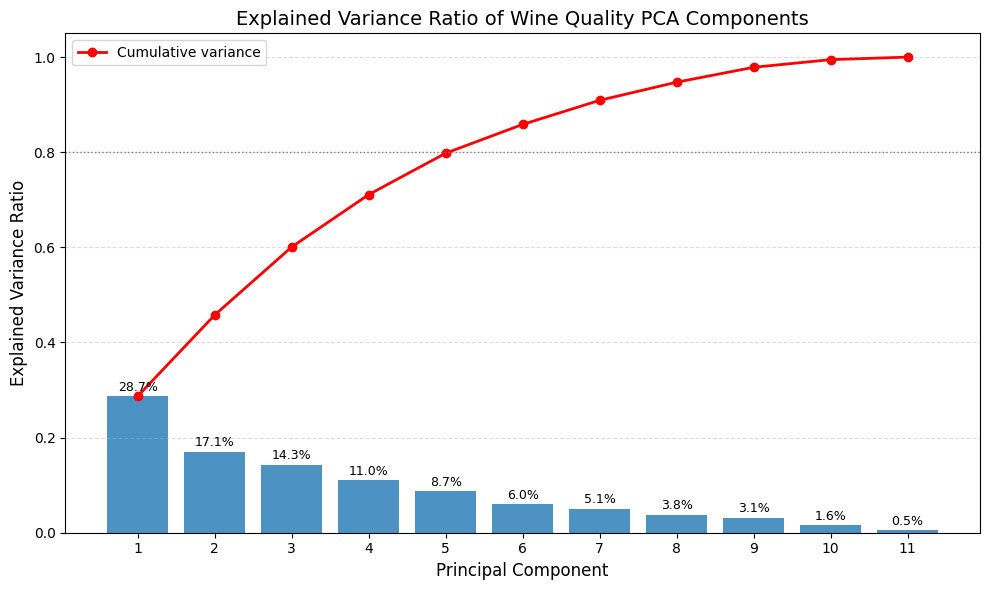

In [12]:
evr = wine_pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, len(evr) + 1), evr, alpha=0.8)

for i, b in enumerate(bars):
    height = b.get_height()
    plt.text(
        b.get_x() + b.get_width() / 2,
        height + 0.005,
        f"{height * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.plot(
    range(1, len(evr) + 1),
    cumulative,
    marker="o",
    linewidth=2,
    color="red",
    label="Cumulative variance"
)

plt.axhline(0.8, color="gray", linestyle=":", linewidth=1)

plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance Ratio", fontsize=12)
plt.title("Explained Variance Ratio of Wine Quality PCA Components", fontsize=14)
plt.xticks(range(1, len(evr) + 1))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

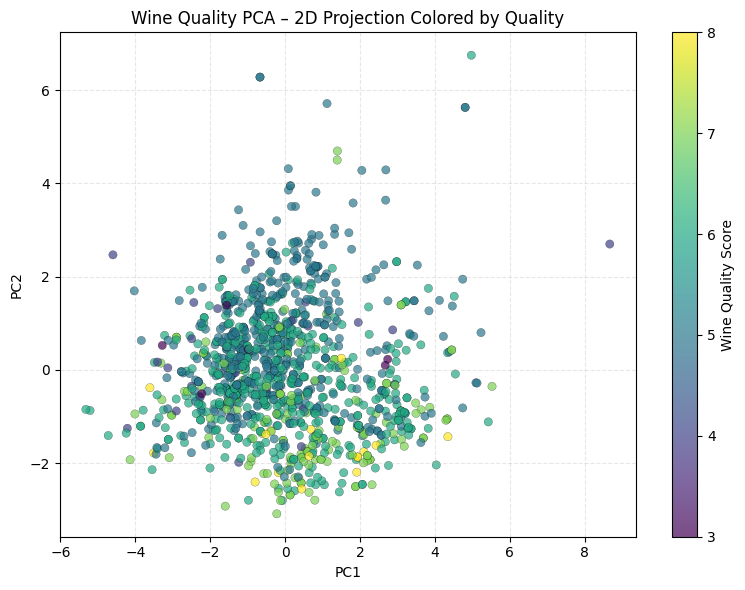

In [14]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=df["quality"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="k",
    linewidths=0.2,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Quality PCA – 2D Projection Colored by Quality")

cbar = plt.colorbar(sc)
cbar.set_label("Wine Quality Score")

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


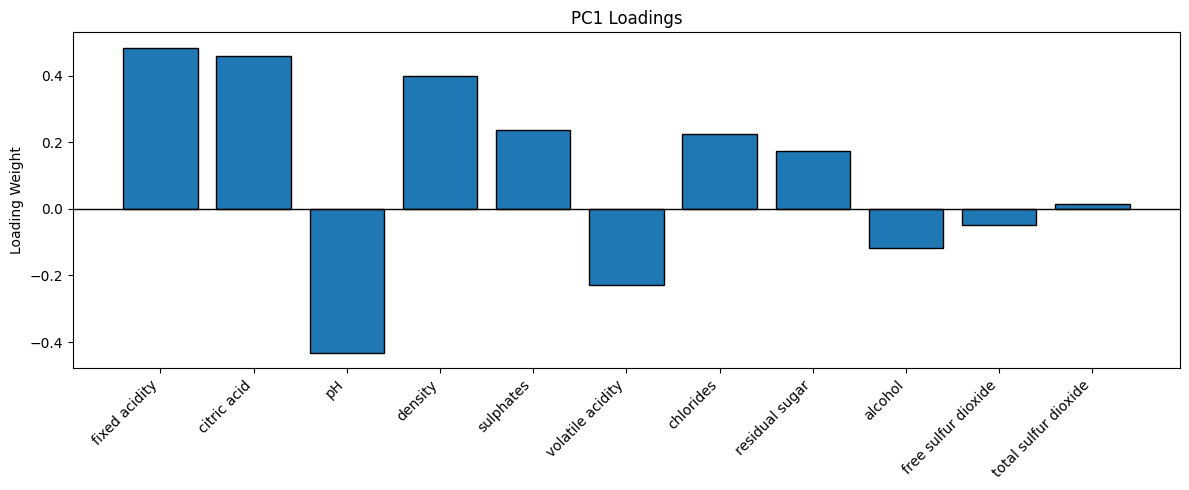

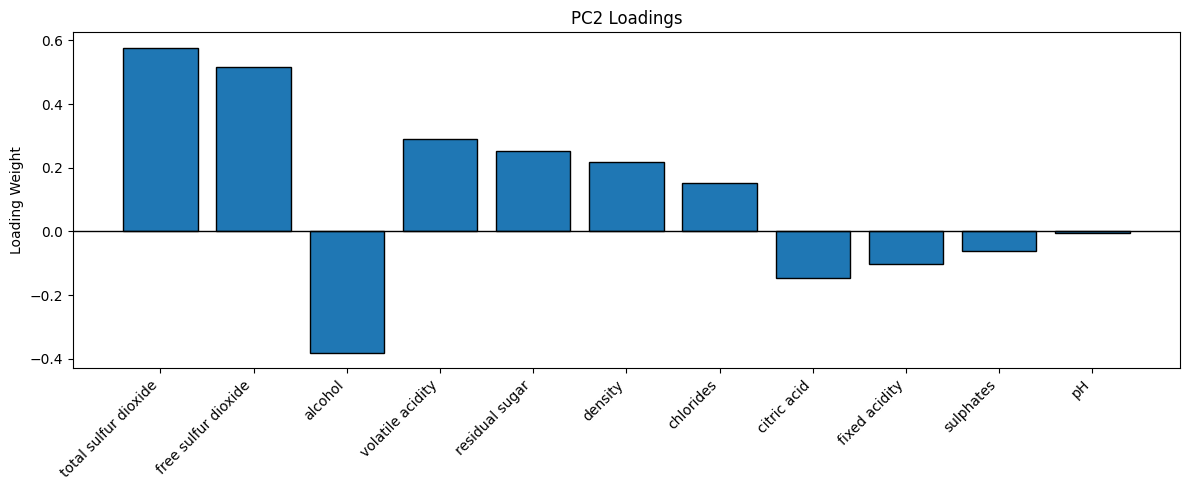

In [17]:
loadings = wine_pca.components_[:2]

idx1 = np.argsort(np.abs(loadings[0]))[::-1]
features1 = np.array(feature_names)[idx1]
vals1 = loadings[0][idx1]

plt.figure(figsize=(12, 5))
bars = plt.bar(features1, vals1, edgecolor="k")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Loading Weight")
plt.title("PC1 Loadings")
plt.tight_layout()
plt.show()

# PC2
idx2 = np.argsort(np.abs(loadings[1]))[::-1]
features2 = np.array(feature_names)[idx2]
vals2 = loadings[1][idx2]

plt.figure(figsize=(12, 5))
bars = plt.bar(features2, vals2, edgecolor="k")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Loading Weight")
plt.title("PC2 Loadings")
plt.tight_layout()
plt.show()

In [21]:
quality = df["quality"].values
pc_df = pd.DataFrame(x_pca, columns=[f"PC{i+1}" for i in range(11)])
pc_df["quality"] = quality

corrs = pc_df.corr()["quality"].drop("quality")
# spearman_corr = pc_df.corr(method="spearman")["quality"]
print(corrs)
# print(spearman_corr)

PC1     0.109777
PC2    -0.405912
PC3     0.405642
PC4    -0.069076
PC5     0.085267
PC6     0.015481
PC7     0.076285
PC8    -0.063489
PC9     0.083362
PC10   -0.057744
PC11   -0.021585
Name: quality, dtype: float64
